In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline 
import numpy as np

In [3]:
(X_train,y_train),(X_test,y_test)= keras.datasets.mnist.load_data()

In [4]:
len(X_train)

60000

In [5]:
len(X_test)

10000

In [6]:
X_train[0].shape

(28, 28)

In [7]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

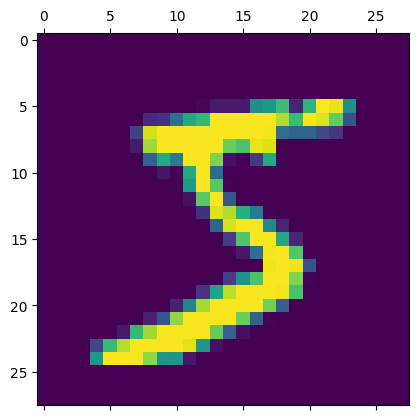

In [8]:
plt.matshow(X_train[0])

In [9]:
y_train[0]

5

In [10]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [11]:
X_train.shape

(60000, 28, 28)

In [12]:
X_train=X_train/255
X_test=X_test/255

In [13]:
#to flatten 2d image to 1d
X_train_flattened= X_train.reshape(len(X_train),28*28)
X_test_flattened= X_test.reshape(len(X_test),28*28)
X_test_flattened.shape
X_train_flattened.shape

(60000, 784)

In [14]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [15]:
#creating a simple neural network
model=keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,),activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened,y_train,epochs=5)


Epoch 1/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.4705 - accuracy: 0.8762
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3039 - accuracy: 0.9154
Epoch 3/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2836 - accuracy: 0.9205
Epoch 4/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2734 - accuracy: 0.9233
Epoch 5/5
1875/1875 [==============================] - 2s 953us/step - loss: 0.2663 - accuracy: 0.9264


In [16]:
model.evaluate(X_test_flattened,y_test)

313/313 [==============================] - 0s 994us/step - loss: 0.2696 - accuracy: 0.9259


[0.2696009576320648, 0.9258999824523926]

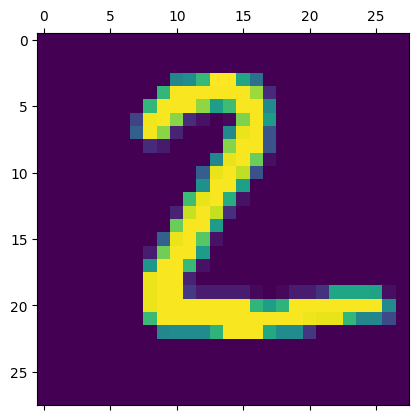

In [17]:
plt.matshow(X_test[1])

In [18]:
y_predicted=model.predict(X_test_flattened)
y_predicted[1]

313/313 [==============================] - 0s 848us/step


array([4.8761573e-01, 7.4677197e-03, 9.9959970e-01, 5.2180398e-01,
       5.1014021e-10, 8.9213639e-01, 8.9043981e-01, 1.1983893e-12,
       2.1704721e-01, 2.2100977e-09], dtype=float32)

In [19]:
np.argmax(y_predicted[1])#helps print the index

2

In [20]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[7, 2, 1, 0, 4]

In [21]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [22]:
#confusion matrix
cm= tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 964,    0,    2,    2,    0,    4,    5,    2,    1,    0],
       [   0, 1108,    3,    2,    0,    1,    4,    2,   15,    0],
       [   4,    9,  925,   19,    8,    2,   11,    8,   43,    3],
       [   2,    0,   18,  934,    1,   18,    2,    6,   22,    7],
       [   2,    1,    5,    2,  919,    0,    8,    3,   11,   31],
       [   7,    2,    5,   40,    7,  777,   11,    2,   35,    6],
       [  11,    3,   10,    1,    8,   17,  903,    2,    3,    0],
       [   1,    5,   26,   11,    9,    1,    0,  928,    5,   42],
       [   5,    6,    6,   21,    9,   28,    8,    4,  881,    6],
       [  10,    5,    1,   12,   30,    8,    0,   10,   13,  920]])>

Text(95.72222222222221, 0.5, 'Truth')

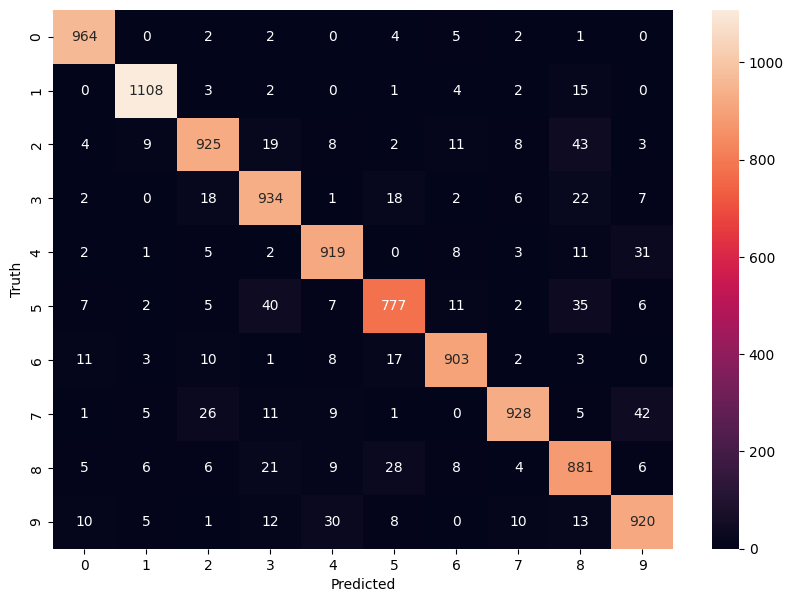

In [23]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [24]:
#adding a hidden layer
model=keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='softmax')

])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened,y_train,epochs=5)


Epoch 1/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2815 - accuracy: 0.9199
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1286 - accuracy: 0.9617
Epoch 3/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0889 - accuracy: 0.9728
Epoch 4/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0669 - accuracy: 0.9793
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0519 - accuracy: 0.9840


In [25]:
model.evaluate(X_test_flattened,y_test)
#accuracy improved from 92 to 97%

313/313 [==============================] - 1s 1ms/step - loss: 0.0806 - accuracy: 0.9765


[0.08062120527029037, 0.9764999747276306]

313/313 [==============================] - 0s 1ms/step


Text(95.72222222222221, 0.5, 'Truth')

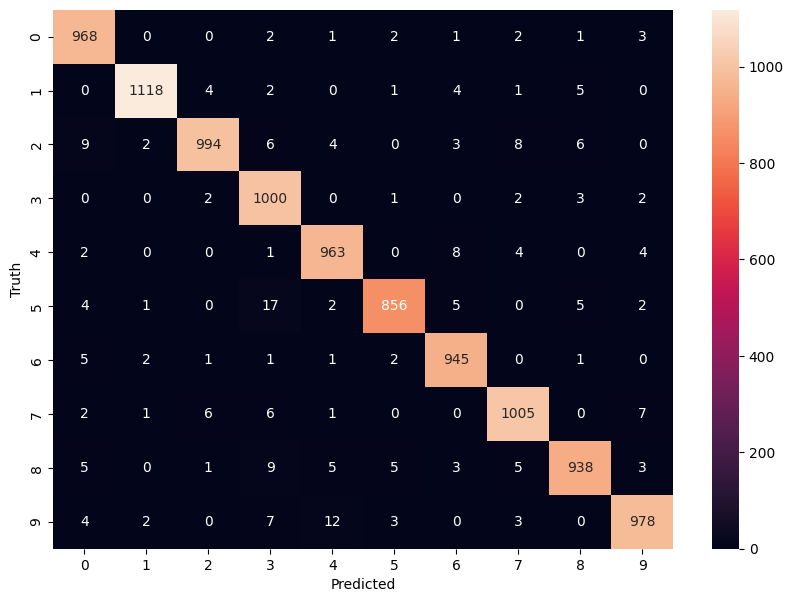

In [26]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]

cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [27]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')

])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train,y_train,epochs=7)


Epoch 1/7
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2667 - accuracy: 0.9247
Epoch 2/7
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1175 - accuracy: 0.9653
Epoch 3/7
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0842 - accuracy: 0.9751
Epoch 4/7
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0639 - accuracy: 0.9807
Epoch 5/7
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0510 - accuracy: 0.9840
Epoch 6/7
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0396 - accuracy: 0.9879
Epoch 7/7
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0329 - accuracy: 0.9899


In [28]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.0798 - accuracy: 0.9767


[0.07975911349058151, 0.9767000079154968]